### Aluno: Lucas Barbosa dos Santos

###0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

###1. Carregar a base de dados

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/Colab Notebooks'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(file_path + '/Life Expectancy Data.csv')

In [ ]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness 1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

###2. Análise exploratória

In [ ]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
#Tratando as variáveis categóricas e temporais
df.drop(columns=['Country', 'Year'], inplace = True)
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Status                           2938 non-null   int64  
 1   Life expectancy                  2928 non-null   float64
 2   Adult Mortality                  2928 non-null   float64
 3   infant deaths                    2938 non-null   int64  
 4   Alcohol                          2744 non-null   float64
 5   percentage expenditure           2938 non-null   float64
 6   Hepatitis B                      2385 non-null   float64
 7   Measles                          2938 non-null   int64  
 8   BMI                              2904 non-null   float64
 9   under-five deaths                2938 non-null   int64  
 10  Polio                            2919 non-null   float64
 11  Total expenditure                2712 non-null   float64
 12  Diphtheria          

In [ ]:
df.describe()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,0.174268,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,0.379405,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,0.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,0.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,0.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,0.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,1.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Population,652
Hepatitis B,553
GDP,448
Total expenditure,226
Alcohol,194
Income composition of resources,167
Schooling,163
BMI,34
thinness 5-9 years,34
thinness 1-19 years,34


In [ ]:
#Excluindo colunas com mais de 15% dos dados nulos:
porcentagem = df.isnull().mean() * 100
cols_aacima_15 = porcentagem[porcentagem > 10]
cols_aacima_15

,0
Hepatitis B,18.822328
GDP,15.248468
Population,22.191967


In [ ]:
df.drop(columns=['GDP','Hepatitis B', "Population"], inplace = True)

In [ ]:
df.head()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,65.0,263.0,62,0.01,71.279624,1154,19.1,83,6.0,8.16,65.0,0.1,17.2,17.3,0.479,10.1
1,0,59.9,271.0,64,0.01,73.523582,492,18.6,86,58.0,8.18,62.0,0.1,17.5,17.5,0.476,10.0
2,0,59.9,268.0,66,0.01,73.219243,430,18.1,89,62.0,8.13,64.0,0.1,17.7,17.7,0.470,9.9
3,0,59.5,272.0,69,0.01,78.184215,2787,17.6,93,67.0,8.52,67.0,0.1,17.9,18.0,0.463,9.8
4,0,59.2,275.0,71,0.01,7.097109,3013,17.2,97,68.0,7.87,68.0,0.1,18.2,18.2,0.454,9.5


In [ ]:
df['Total expenditure'] = df['Total expenditure'].fillna(df['Total expenditure'].median())
df['Alcohol'] = df['Alcohol'].fillna(df['Alcohol'].median())
df['Income composition of resources'] = df['Income composition of resources'].fillna(df['Income composition of resources'].median())
df['Schooling'] = df['Schooling'].fillna(df['Schooling'].median())

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
BMI,34
thinness 1-19 years,34
thinness 5-9 years,34
Diphtheria,19
Polio,19
Adult Mortality,10
Life expectancy,10
Status,0
infant deaths,0
under-five deaths,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2888 entries, 0 to 2937
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Status                           2888 non-null   int64  
 1   Life expectancy                  2888 non-null   float64
 2   Adult Mortality                  2888 non-null   float64
 3   infant deaths                    2888 non-null   int64  
 4   Alcohol                          2888 non-null   float64
 5   percentage expenditure           2888 non-null   float64
 6   Measles                          2888 non-null   int64  
 7   BMI                              2888 non-null   float64
 8   under-five deaths                2888 non-null   int64  
 9   Polio                            2888 non-null   float64
 10  Total expenditure                2888 non-null   float64
 11  Diphtheria                       2888 non-null   float64
 12  HIV/AIDS                 

In [ ]:
df.describe()

,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000
mean,0.177285,69.349377,163.357341,30.314751,4.589971,749.475611,2442.514543,38.221087,41.985803,82.672091,5.918660,82.437673,1.749792,4.850589,4.881337,0.635006,12.126489
std,0.381976,9.495441,124.018934,118.891670,3.934474,2003.090073,11561.322467,19.962630,161.743345,23.333655,2.390235,23.648907,5.116551,4.421403,4.510414,0.200672,3.107625
min,0.000000,36.300000,1.000000,0.000000,0.010000,0.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,0.100000,0.100000,0.000000,0.000000
25%,0.000000,63.475000,73.000000,0.000000,1.107500,5.049462,0.000000,19.300000,0.000000,78.000000,4.370000,78.000000,0.100000,1.600000,1.500000,0.511750,10.400000
50%,0.000000,72.200000,143.000000,3.000000,3.755000,67.687008,17.000000,43.250000,4.000000,93.000000,5.755000,93.000000,0.100000,3.350000,3.400000,0.677000,12.300000
75%,0.000000,75.800000,225.000000,21.000000,7.490000,454.422430,352.250000,56.100000,26.000000,97.000000,7.322500,97.000000,0.800000,7.200000,7.200000,0.774000,14.200000
max,1.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,212183.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,50.600000,27.700000,28.600000,0.948000,20.700000


<ipython-input-81-684cda149184>:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax, grid=True)


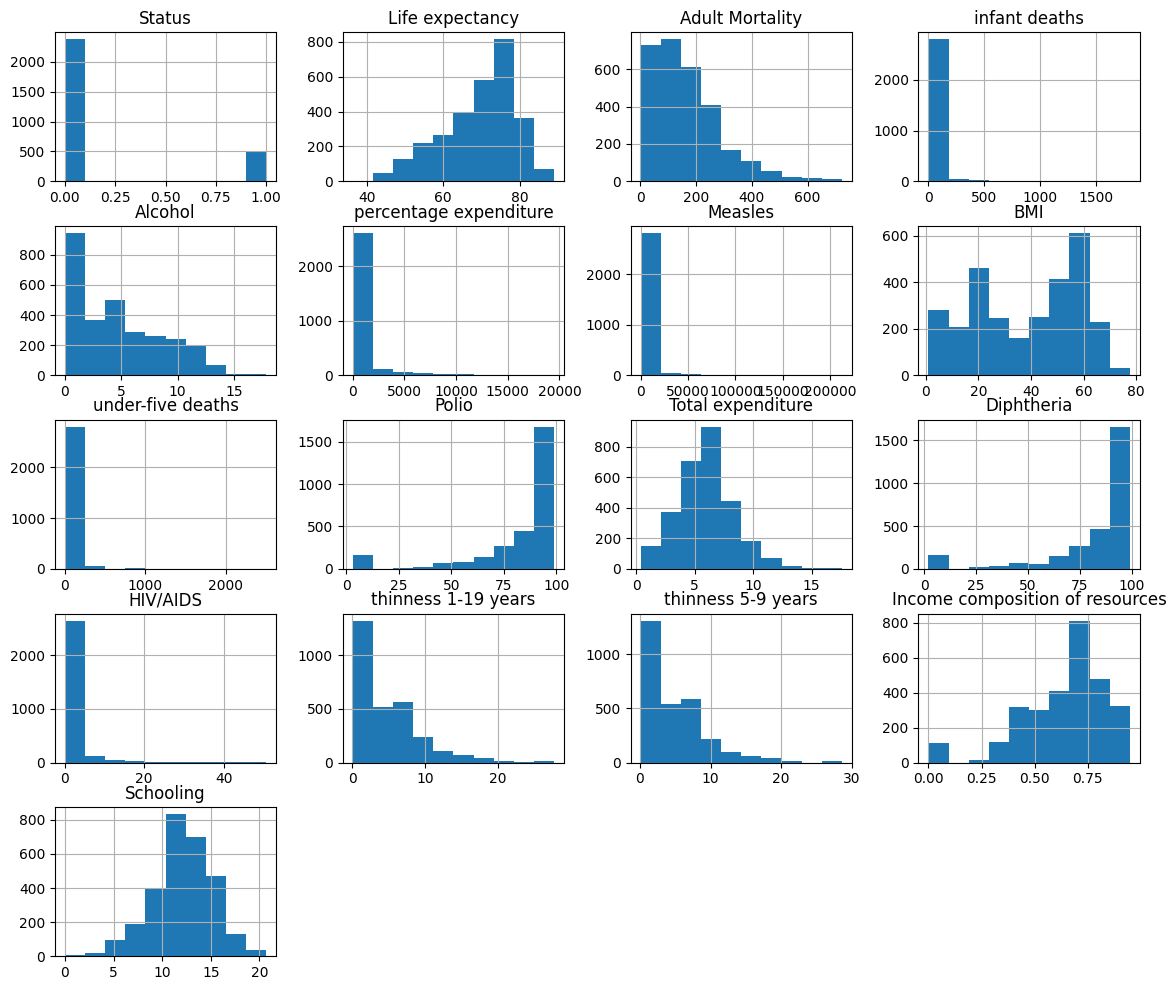

In [ ]:
fig = plt.figure(figsize = (14,12))
ax = fig.gca()
df.hist(ax = ax, grid=True)
plt.title("Dispersão dos dados")
plt.show()

<Axes: >

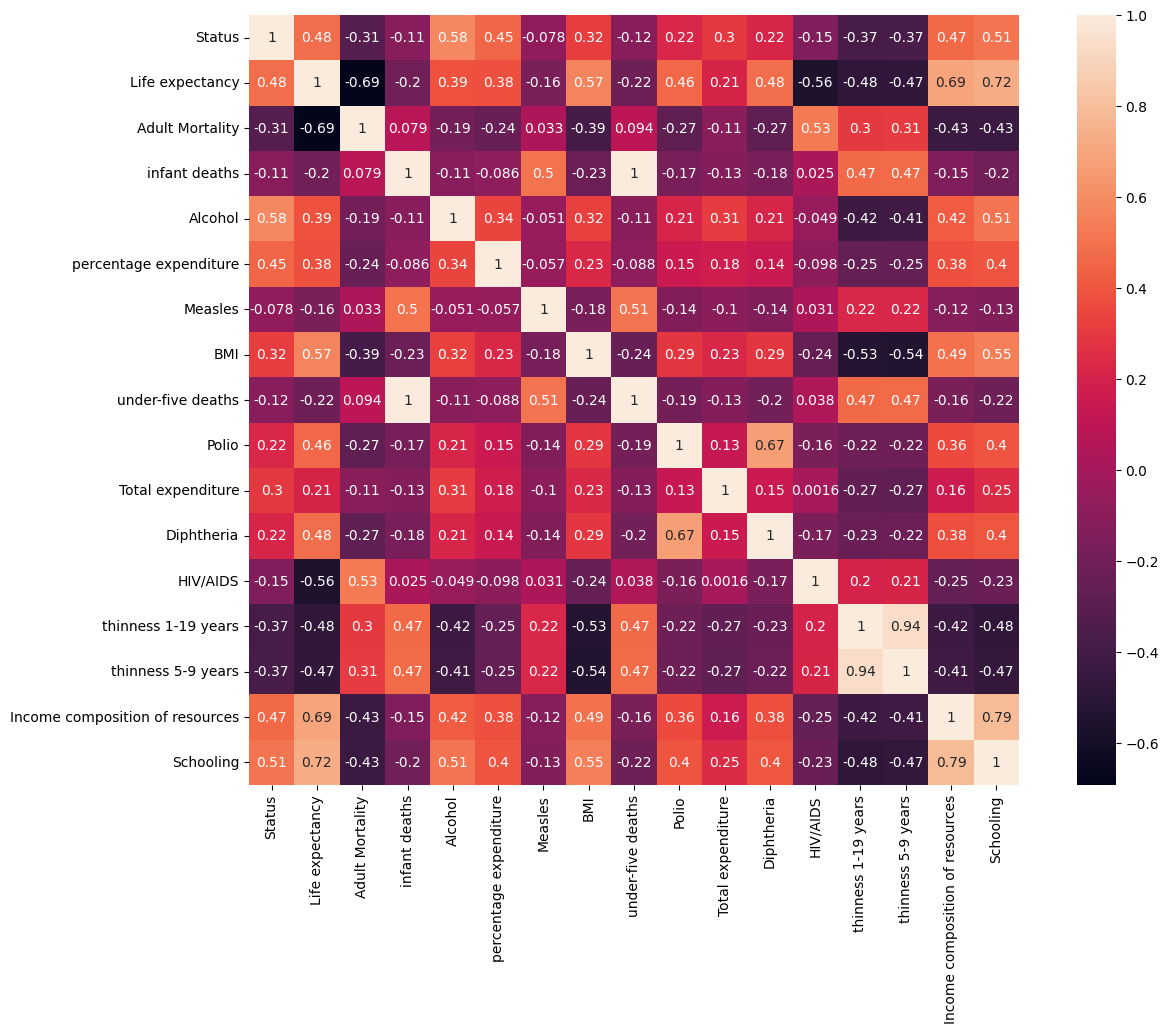

In [ ]:
plt.figure(figsize = (15, 10))
sns.heatmap(df.corr(),annot=True, square=True)

In [ ]:
# As features com maior correlação positiva (ou seja, à medida que elas aumentam, a expectativa de vida também tende a aumentar) são:
# Income composition of resources (0.79)
# Schooling (0.72)
# BMI (0.57)
# Status (0.48)
# Polio (0.46)
# Diphtheria (0.47)
# Essas variáveis estão associadas a fatores de desenvolvimento humano, como educação, nutrição e vacinação, o que naturalmente contribui para uma maior expectativa de vida.
# As features com maior correlação negativa (ou seja, quanto maiores seus valores, menor tende a ser a expectativa de vida) são:
# Adult Mortality (-0.69)
# infant deaths (-0.58)
# HIV/AIDS (-0.56)
# under-five deaths (-0.55)
# thinness 1-19 years (-0.47)
# thinness 5-9 years (-0.48)
# Essas variáveis representam condições de saúde precárias, mortalidade infantil e desnutrição, que estão fortemente associadas à redução da expectativa de vida.

In [ ]:
 # As variáveis thinness 1-19 years e thinness 5-9 years possuem uma correlação muito alta entre si, aproximadamente 0.94.
 # Essas duas features são praticamente redundantes: ambas carregam praticamente a mesma informação no contexto do dataset.

In [ ]:
# Ambas têm correlação negativa com a expectativa de vida, e valores muito próximos entre si.
# Mas thinness 5-9 years tem correlação ligeiramente mais forte (-0.48) com Life expectancy do que thinness 1-19 years (-0.47).

In [ ]:
# Sim, o dataset tem potencial real para predizer Life expectancy, com base nas boas correlações observadas entre as features e a variável de saída.
# há relações significativas e consistentes entre várias variáveis e a expectativa de vida.
# Além disso, as variáveis têm diversidade de tipos — mortalidade, educação, renda, vacinação — o que permite ao modelo capturar diferentes aspectos do problema.

In [ ]:
df.drop(columns=['thinness 1-19 years'], inplace = True)

###3. Divisão de treinamento e teste

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Life expectancy']),
                                                    df['Life expectancy'],
                                                    test_size=0.3,
                                                    random_state=111)

In [ ]:
pd.DataFrame(X_train).head(5)

,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,thinness 5-9 years,Income composition of resources,Schooling
1093,0,285.0,4,0.01,0.948526,0,24.3,6,87.0,5.96,87.0,5.3,7.5,0.416,9.1
2058,1,81.0,0,11.96,331.457035,23,59.5,0,98.0,9.74,98.0,0.1,0.5,0.824,16.3
354,0,146.0,46,7.24,916.270845,220,54.5,52,96.0,8.48,97.0,0.1,2.7,0.734,14.2
310,0,27.0,10,3.87,0.000000,0,48.6,12,92.0,5.76,93.0,0.2,1.1,0.636,13.8
2527,1,6.0,0,10.15,14714.825880,958,55.0,0,96.0,11.00,95.0,0.1,0.4,0.916,15.3


###4. Tratamento dos dados

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled[:3]

array([[-0.48121317,  1.01005678, -0.21501139, -1.17520161, -0.37904807,
        -0.2122179 , -0.71617943, -0.21572011,  0.17541707,  0.01138944,
         0.18983969,  0.68585066,  0.63594811, -1.12510746, -1.00835055],
       [ 2.0780811 , -0.64421665, -0.24679387,  1.85133774, -0.22516784,
        -0.21035531,  1.0482562 , -0.25078428,  0.65461304,  1.6010168 ,
         0.65432638, -0.31969367, -0.96154433,  0.92350305,  1.3365443 ],
       [-0.48121317, -0.11711972,  0.11870465,  0.65591801,  0.04711344,
        -0.19440185,  0.79762614,  0.05310518,  0.5674865 ,  1.07114101,
         0.61210032, -0.31969367, -0.45947528,  0.47160367,  0.65261663]])

In [ ]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2021 entries, 1093 to 2017
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Status                           2021 non-null   float64
 1   Adult Mortality                  2021 non-null   float64
 2   infant deaths                    2021 non-null   float64
 3   Alcohol                          2021 non-null   float64
 4   percentage expenditure           2021 non-null   float64
 5   Measles                          2021 non-null   float64
 6   BMI                              2021 non-null   float64
 7   under-five deaths                2021 non-null   float64
 8   Polio                            2021 non-null   float64
 9   Total expenditure                2021 non-null   float64
 10  Diphtheria                       2021 non-null   float64
 11  HIV/AIDS                         2021 non-null   float64
 12  thinness 5-9 years    

In [ ]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_test_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 867 entries, 390 to 1533
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Status                           867 non-null    float64
 1   Adult Mortality                  867 non-null    float64
 2   infant deaths                    867 non-null    float64
 3   Alcohol                          867 non-null    float64
 4   percentage expenditure           867 non-null    float64
 5   Measles                          867 non-null    float64
 6   BMI                              867 non-null    float64
 7   under-five deaths                867 non-null    float64
 8   Polio                            867 non-null    float64
 9   Total expenditure                867 non-null    float64
 10  Diphtheria                       867 non-null    float64
 11  HIV/AIDS                         867 non-null    float64
 12  thinness 5-9 years      

###Regressão Linear

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred = modelo.predict(X_test_scaled)

####Avaliação da Regressão Linear

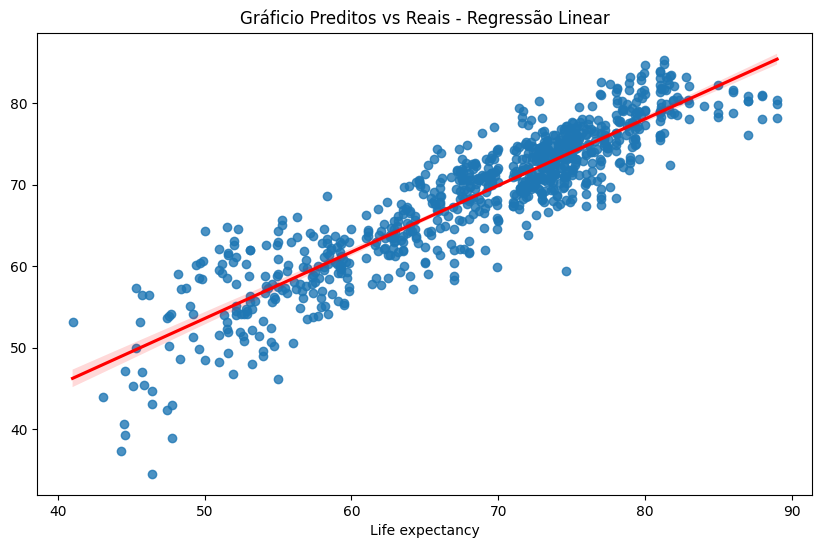

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Regressão Linear')
sns.regplot(x=y_test,y=y_pred,line_kws={"color": "red"})
plt.show()

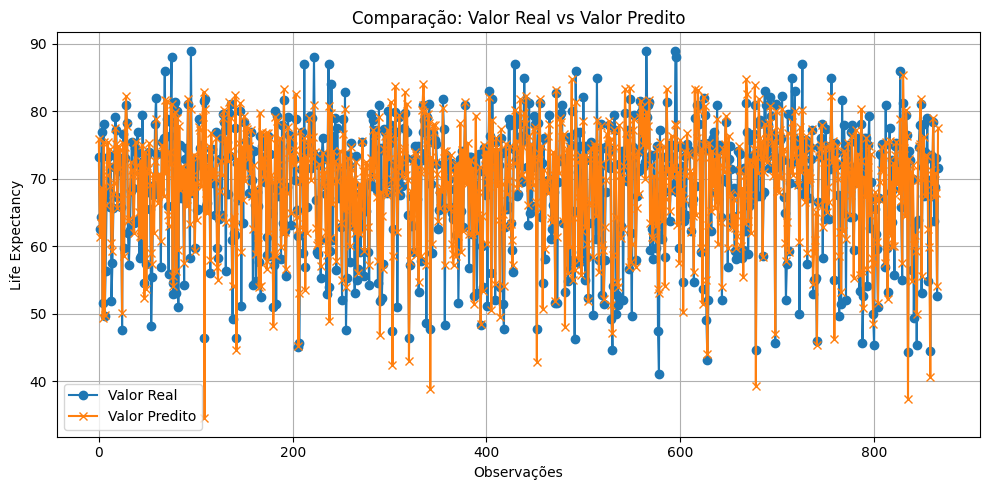

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Valor Real', marker='o')
plt.plot(y_pred, label='Valor Predito', marker='x')
plt.title('Comparação: Valor Real vs Valor Predito')
plt.xlabel('Observações')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

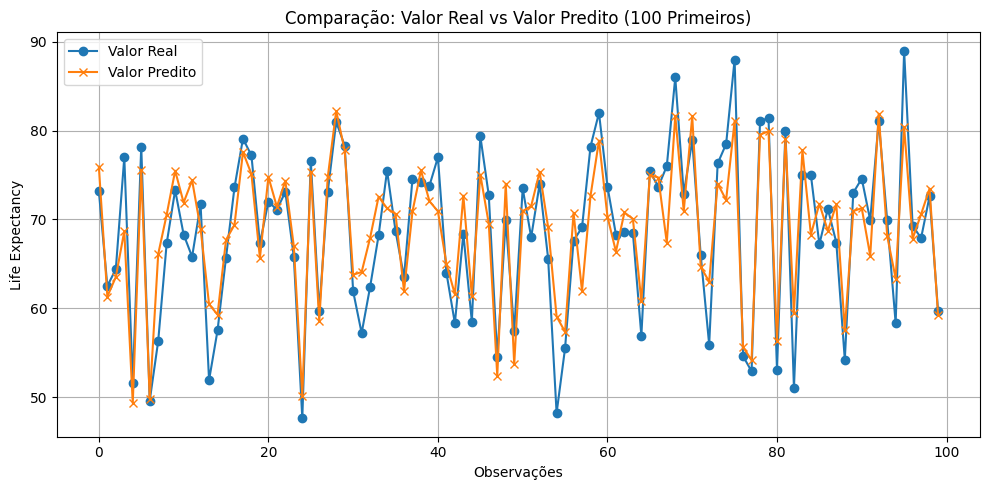

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Valor Real', marker='o')
plt.plot(y_pred[:100], label='Valor Predito', marker='x')
plt.title('Comparação: Valor Real vs Valor Predito (100 Primeiros)')
plt.xlabel('Observações')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

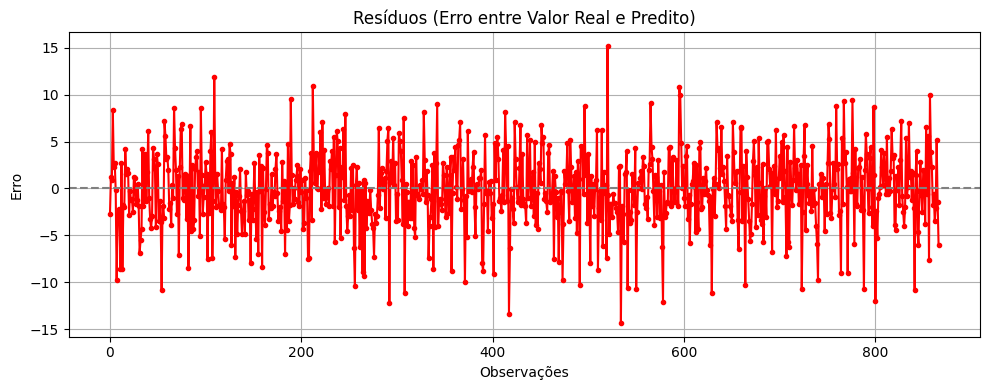

In [ ]:
residuos = y_test.values - y_pred
plt.figure(figsize=(10, 4))
plt.plot(residuos, color='red', marker='.')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Resíduos (Erro entre Valor Real e Predito)')
plt.xlabel('Observações')
plt.ylabel('Erro')
plt.grid(True)
plt.tight_layout()
plt.show()

Com base nas visualizações gerada é possível concluir que o modelo conseguiu predizer razoavelmente bem a variável de interesse.

Os gráficos de dispersão entre os valores reais e os valores previstos mostram que os pontos estão distribuídos próximos à linha de identidade (linha 45º), o que indica que as previsões estão, em sua maioria, alinhadas com os valores esperados. Além disso, a análise dos resíduos revelou uma distribuição aproximadamente simétrica em torno de zero, sem a presença de padrões evidentes ou tendências sistemáticas, o que sugere que o modelo não apresenta viés significativo e que os erros são aleatórios.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

In [ ]:
def print_metrics(y_test_in, y_test_pred_in):
  print("MEAN: ", mean_absolute_error(y_test_in, y_test_pred_in))
  print("MAPE: ", mean_absolute_percentage_error(y_test_in, y_test_pred_in))
  print("MSE: ", mean_squared_error(y_test_in, y_test_pred_in))
  print("RMSE: ", mean_squared_error(y_test_in, y_test_pred_in)**0.5)
  print("R²: ", r2_score(y_test_in, y_test_pred_in))

In [ ]:
print_metrics(y_test, y_pred)

MEAN:  3.057898642300606
MAPE:  0.0470467100293032
MSE:  15.967679239584399
RMSE:  3.9959578625886936
R²:  0.8232006203266353


Os valores das métricas também reforçam a conclusão das visualizações: o erro percentual médio (MAPE) ficou em torno de 4,7%, considerado muito bom para problemas de regressão, e o coeficiente de determinação (R²) de aproximadamente 0,82 indica que o modelo explica uma grande parte da variabilidade dos dados. O RMSE baixo, em comparação à escala dos dados, também aponta para uma boa capacidade preditiva.

Portanto, tanto as visualizações quanto as métricas quantitativas indicam que o modelo apresentou um desempenho satisfatório e é capaz de fazer previsões com boa precisão.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
modelo = LinearRegression()
X = df.drop(columns='Life expectancy')
y = df['Life expectancy']
scores = cross_val_score(modelo, X, y, cv=10, scoring='r2')
print("Scores em cada fold:", scores)
print("Score médio:", np.mean(scores))

Scores em cada fold: [0.76795521 0.80361964 0.81995694 0.79384592 0.7438928  0.83995388
 0.72726834 0.65369442 0.81252489 0.79635227]
Score médio: 0.7759064315584401


In [ ]:
import xgboost as xgb

In [ ]:
model = xgb.XGBRegressor()
model.fit(X_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred_XG = model.predict(X_test_scaled)

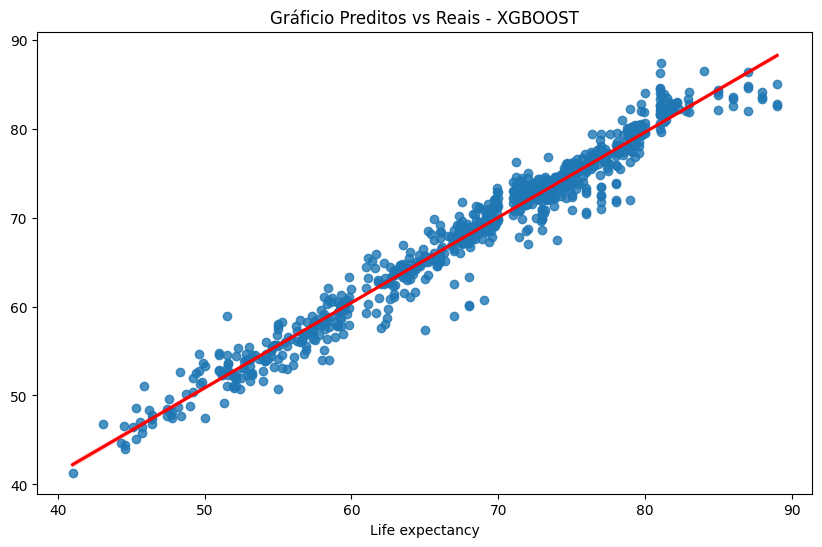

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - XGBOOST')
sns.regplot(x=y_test,y=y_pred_XG,line_kws={"color": "red"})
plt.show()

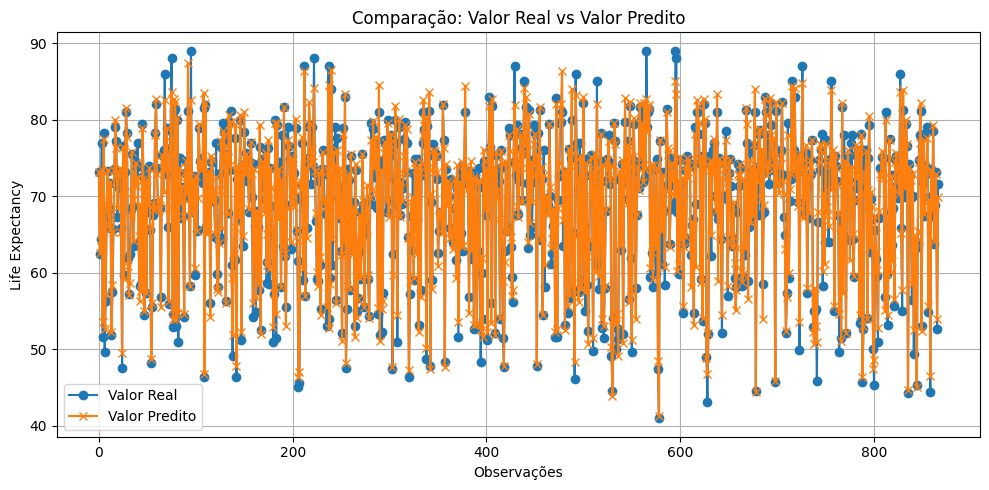

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Valor Real', marker='o')
plt.plot(y_pred_XG, label='Valor Predito', marker='x')
plt.title('Comparação: Valor Real vs Valor Predito')
plt.xlabel('Observações')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

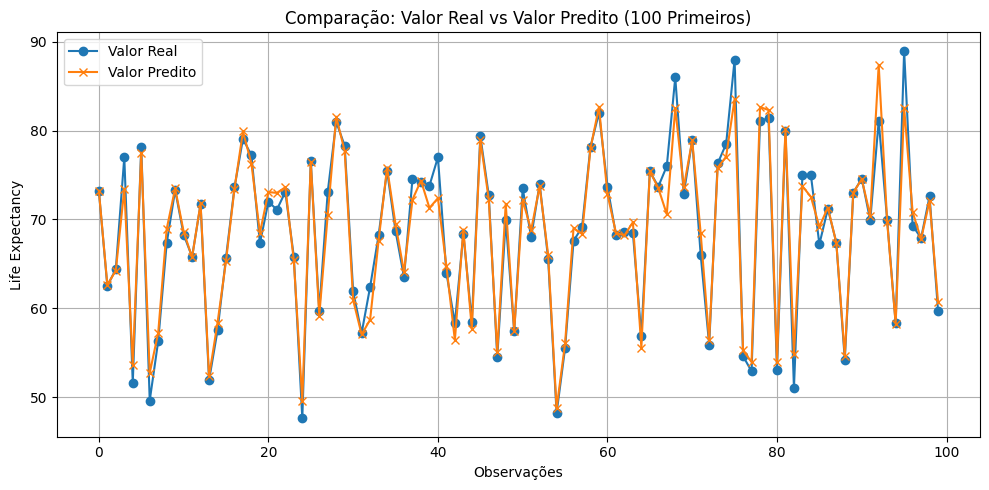

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:100], label='Valor Real', marker='o')
plt.plot(y_pred_XG[:100], label='Valor Predito', marker='x')
plt.title('Comparação: Valor Real vs Valor Predito (100 Primeiros)')
plt.xlabel('Observações')
plt.ylabel('Life Expectancy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

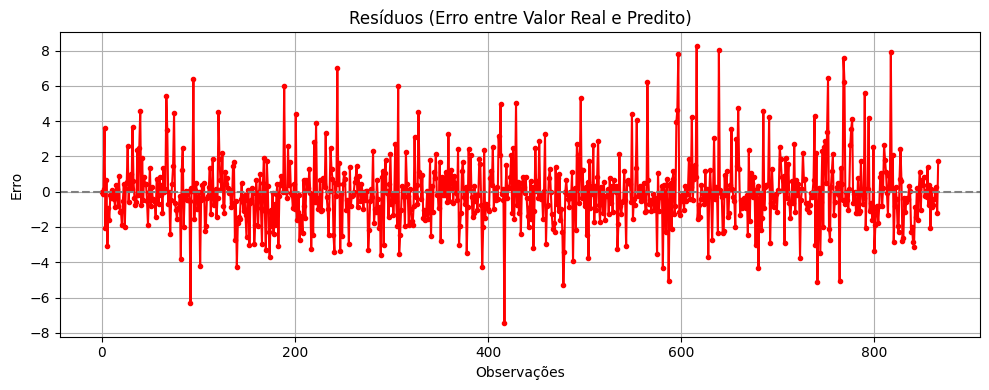

In [ ]:
residuos = y_test.values - y_pred_XG
plt.figure(figsize=(10, 4))
plt.plot(residuos, color='red', marker='.')
plt.axhline(0, color='gray', linestyle='--')
plt.title('Resíduos (Erro entre Valor Real e Predito)')
plt.xlabel('Observações')
plt.ylabel('Erro')
plt.grid(True)
plt.tight_layout()
plt.show()

Os gráficos de dispersão entre os valores reais e os valores previstos mostram uma aderência ainda maior dos pontos à linha de identidade, evidenciando que as previsões estão muito próximas dos valores reais. Além disso, a análise dos resíduos revela uma distribuição centrada em torno de zero, sem a presença de padrões ou tendências sistemáticas, o que indica que os erros são essencialmente aleatórios e o modelo não apresenta viés.

In [ ]:
print_metrics(y_test, y_pred_XG)

MEAN:  1.256932627536021
MAPE:  0.01880385585389415
MSE:  3.3495205015412135
RMSE:  1.8301695280878254
R²:  0.9629130108395692


As métricas numéricas reforçam essa interpretação: o MAPE foi de aproximadamente 1,88%, um valor extremamente baixo, indicando que os erros relativos nas previsões são mínimos. O MSE e o RMSE também apresentaram valores baixos, evidenciando que o erro absoluto das previsões é pequeno. Além disso, o coeficiente de determinação (R²) atingiu 0,96, demonstrando que o modelo consegue explicar 96% da variabilidade dos dados — um desempenho excelente para problemas de regressão.

Portanto, tanto pelas visualizações quanto pelas métricas quantitativas, conclui-se que o modelo baseado no XGBoost previu a saída com alta precisão

In [ ]:
model = xgb.XGBRegressor()
X = df.drop(columns='Life expectancy')
y = df['Life expectancy']
scores = cross_val_score(model, X, y, cv=10, scoring='r2')
print("Scores em cada fold:", scores)
print("Score médio:", np.mean(scores))

Scores em cada fold: [0.89347329 0.9419209  0.87986764 0.88891389 0.89481575 0.93601385
 0.92906782 0.8678537  0.88978918 0.9274229 ]
Score médio: 0.9049138912976875


## Conclusão

Ao comparar os resultados dos dois modelos, é possível observar diferenças significativas no desempenho de predição. O modelo de regressão linear apresentou uma boa performance com um R² de 0.823, indicando que ele é capaz de explicar 82,3% da variabilidade dos dados. O MAPE de 4,7% e o RMSE de 4.00 são valores razoáveis, sugerindo que o modelo consegue prever a saída com uma margem de erro relativamente pequena.

No entanto, ao aplicar o algoritmo XGBoost, as métricas melhoraram substancialmente. O R² aumentou para 0.963, o que indica que o modelo XGBoost explicou 96,3% da variabilidade dos dados, uma melhora significativa em relação ao modelo de regressão linear. Além disso, o MAPE foi reduzido para 1,88% e o RMSE caiu para 1.83, o que revela que o modelo XGBoost tem um desempenho preditivo muito mais preciso e robusto.

Em termos de precisão, o modelo XGBoost se destacou não apenas pelas métricas quantitativas, mas também pelas visualizações, onde os valores previstos se alinharam muito mais estreitamente aos valores reais. A distribuição dos resíduos também foi mais equilibrada e simétrica para o modelo XGBoost, indicando um erro de predição mais aleatório e menos tendencioso.

Conclusão final: O modelo XGBoost apresentou um desempenho superior ao modelo de regressão linear em termos de precisão preditiva e capacidade de explicação dos dados, tornando-o a melhor escolha para esse problema específico. No entanto, a regressão linear ainda pode ser uma opção válida em contextos onde a interpretabilidade do modelo seja uma prioridade, já que é mais simples de entender e ajustar.